# Pacotes

In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

In [2]:
from functions.feature_selection import FeatureSelectionOrchestrator
from utils.plots import Pearson_correlation, Bar_plot, plot_numerical_data
from Regression.house_prices.src.features.feat_eng_pipeline import PreprocessingOrchestrator
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Config

In [4]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

# Load dataset

In [5]:
X_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['processed'],
            "train_features.parquet")
    )
y_train = X_train[config_pipe['features']['target'][0]]

In [6]:
X_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2010,WD,Normal,142125


# Features analysis

## Apply Pipeline

In [7]:
preprocessor = PreprocessingOrchestrator(
    numerical_con_1=config_pipe['features']['pipeline1']['num_con_1'],
    numerical_con_2=config_pipe['features']['pipeline1']['num_con_2'],
    numerical_dis=config_pipe['features']['pipeline1']['num_dis_1'],
    categorical_var=config_pipe['features']['pipeline1']['cat_var']
    )
pipe = preprocessor.apply("pipeline1")    
X_train_trans = pipe.fit_transform(X_train)

In [8]:
X_train_trans

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,...,categorical_pipe__BsmtQual_Gd,categorical_pipe__BsmtQual_TA,categorical_pipe__BsmtCond_TA,categorical_pipe__BsmtExposure_No,categorical_pipe__BsmtExposure_Rare,categorical_pipe__KitchenQual_Gd,categorical_pipe__KitchenQual_TA,categorical_pipe__SaleType_WD,categorical_pipe__SaleCondition_Normal,num_con_1_robust__TotalBsmtSF
0,20.108111,8.809113,7,7,8,0,6,8,7,2,...,1,0,1,1,0,1,0,1,1,-0.306895
1,20.647115,8.390301,0,7,0,8,0,8,6,2,...,1,0,1,0,1,0,1,1,1,0.534992
2,21.332458,8.869521,6,7,8,0,5,8,7,2,...,1,0,1,0,1,1,0,1,1,-0.174184
3,20.624842,8.814783,0,6,8,0,5,8,7,1,...,0,1,0,1,0,1,0,1,0,-0.514256
4,22.389555,9.159469,7,7,9,7,7,9,8,2,...,1,0,1,0,0,1,0,1,1,0.292379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,19.837050,8.757060,0,0,8,0,5,8,6,2,...,1,0,1,1,0,0,1,1,1,-0.105754
1456,22.032293,9.077412,6,7,0,8,0,8,6,2,...,1,0,1,1,0,0,1,1,1,1.115604
1457,20.392798,9.247438,0,6,9,0,6,7,7,2,...,0,1,0,1,0,1,0,1,1,0.306895
1458,20.698855,8.175244,0,4,0,8,0,7,5,1,...,0,1,1,0,1,1,0,1,1,0.153447


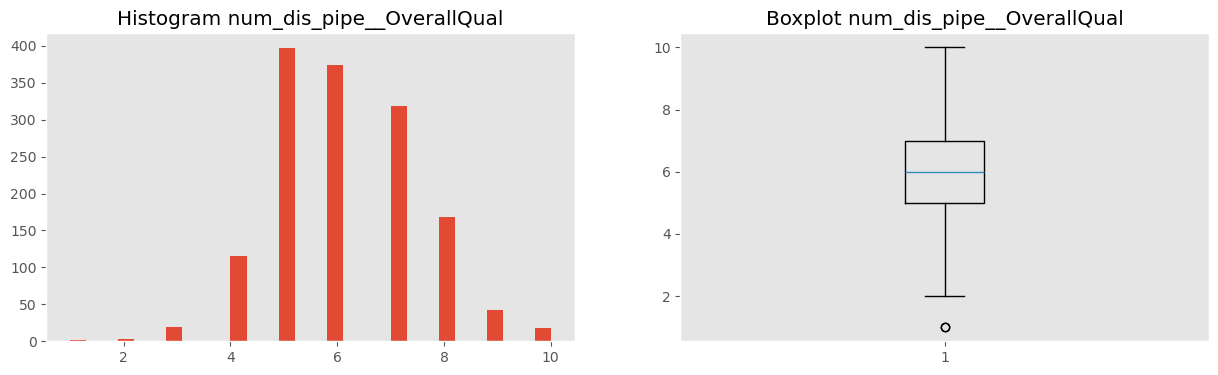

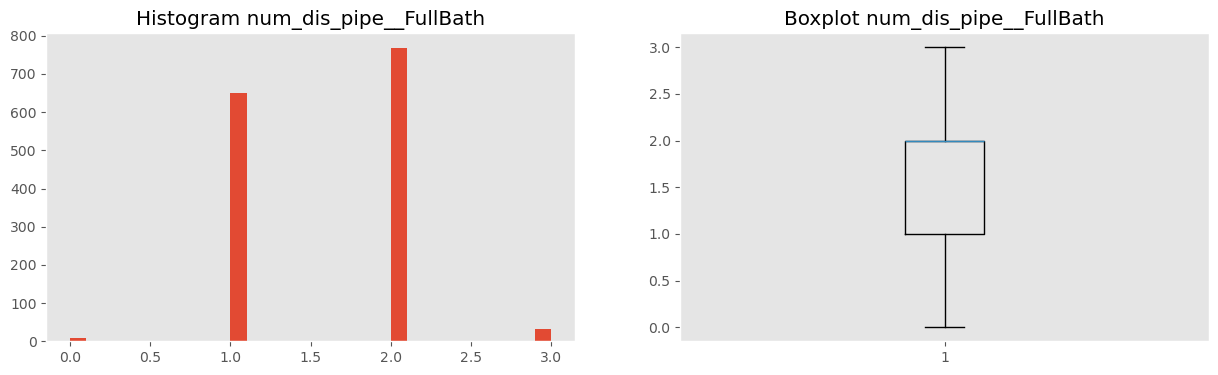

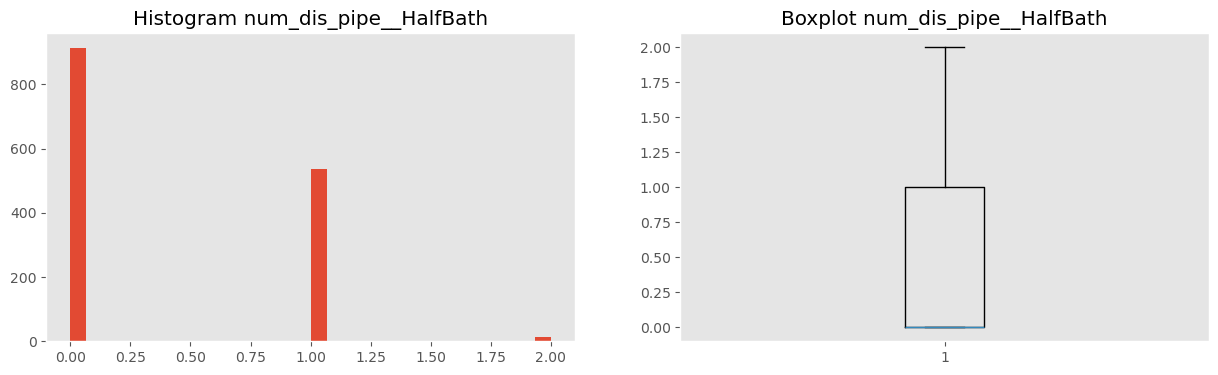

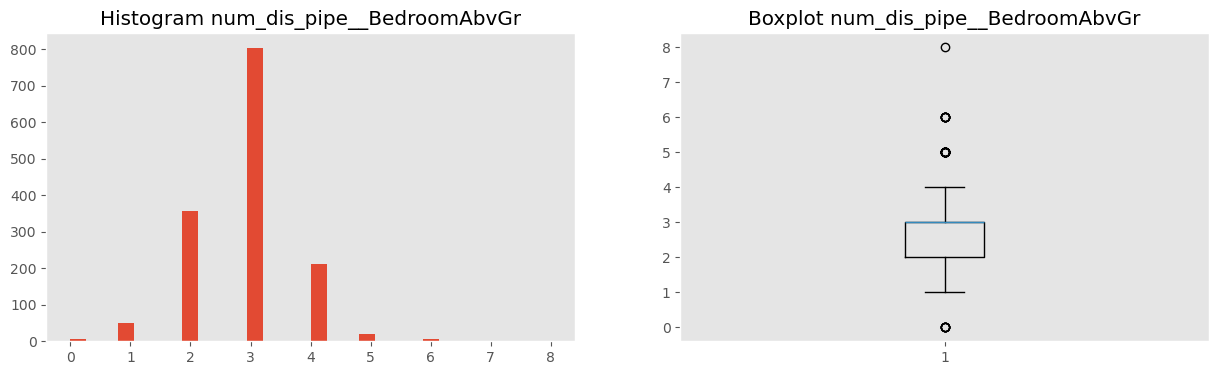

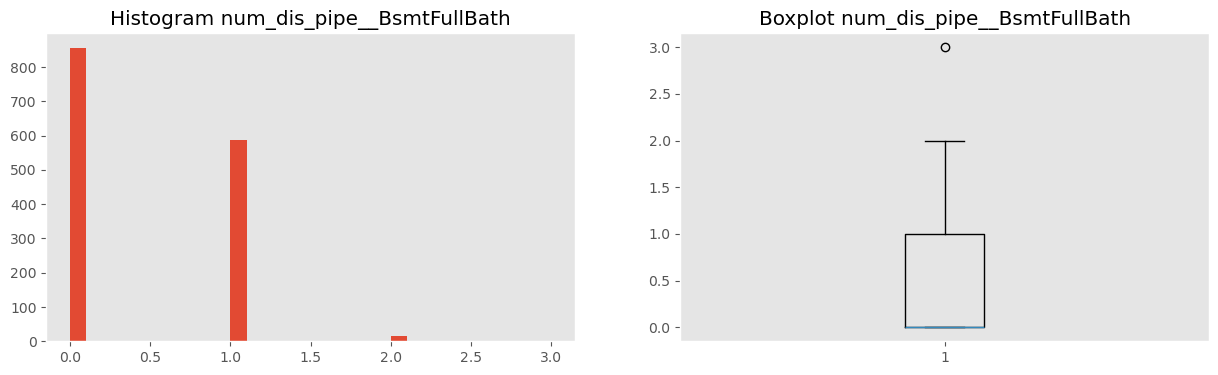

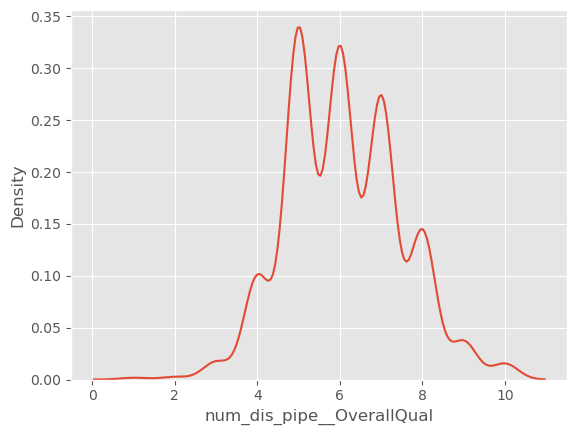

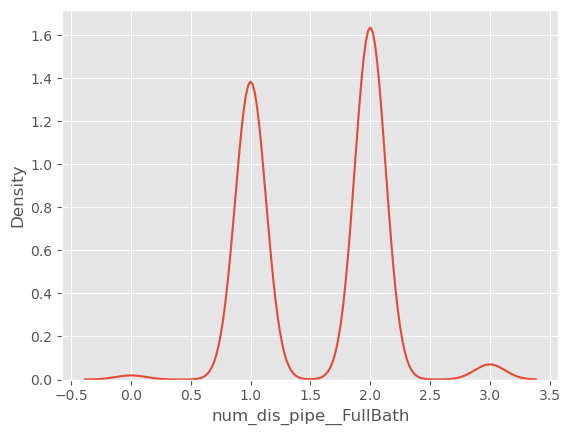

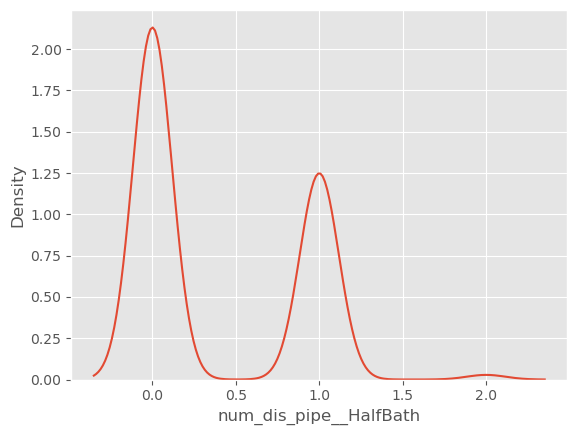

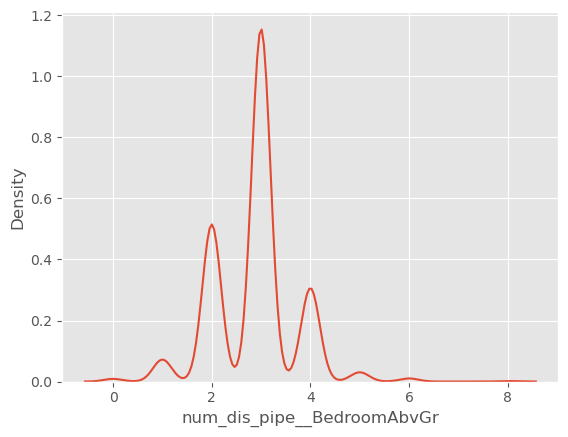

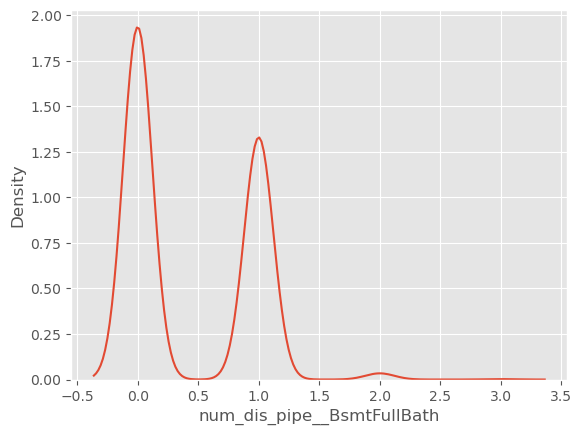

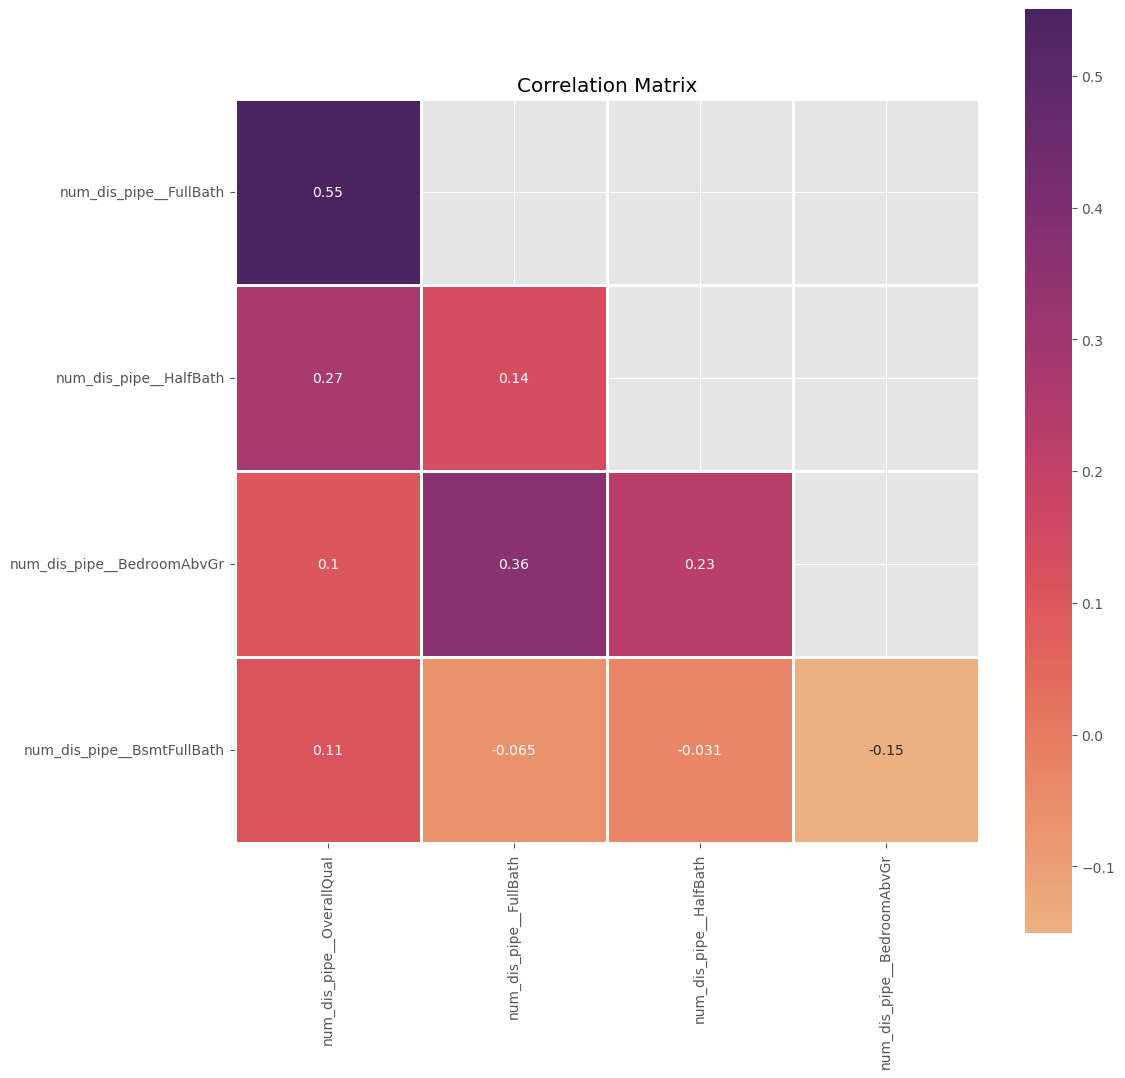

In [9]:
plot_numerical_data(X_train_trans.filter(regex='num_dis_pipe'), target=None)

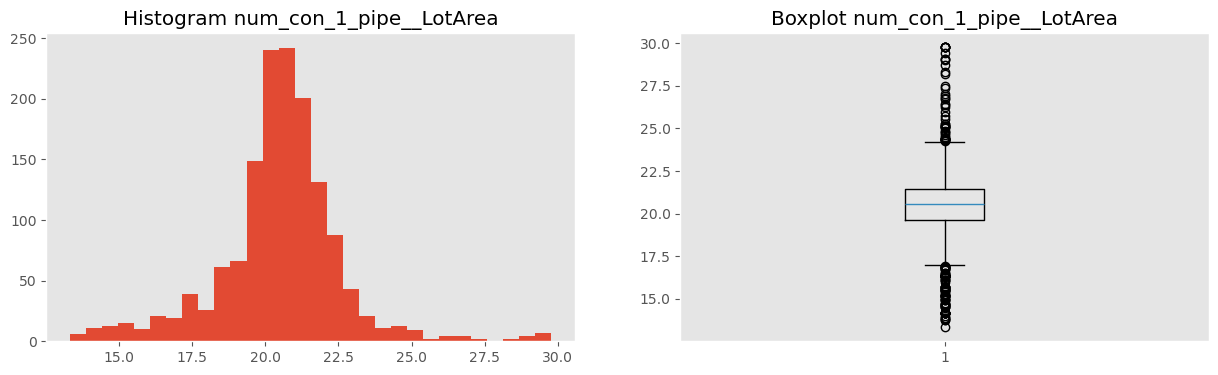

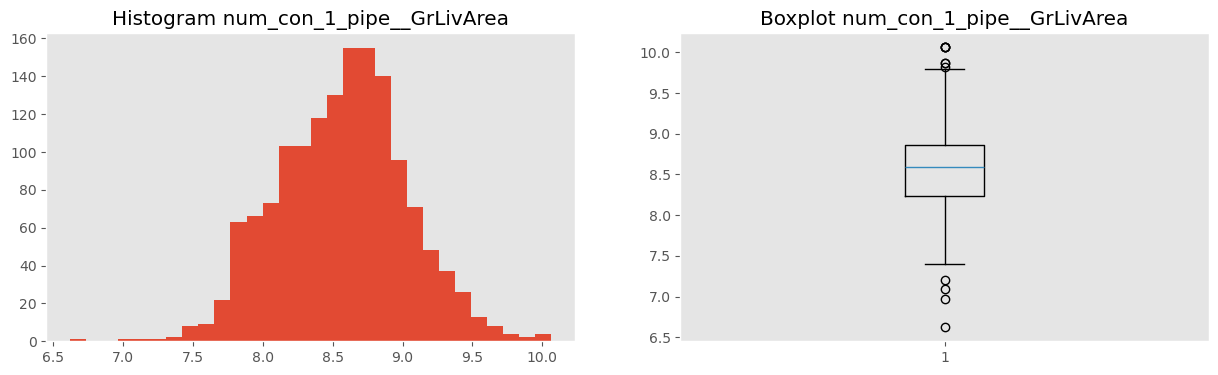

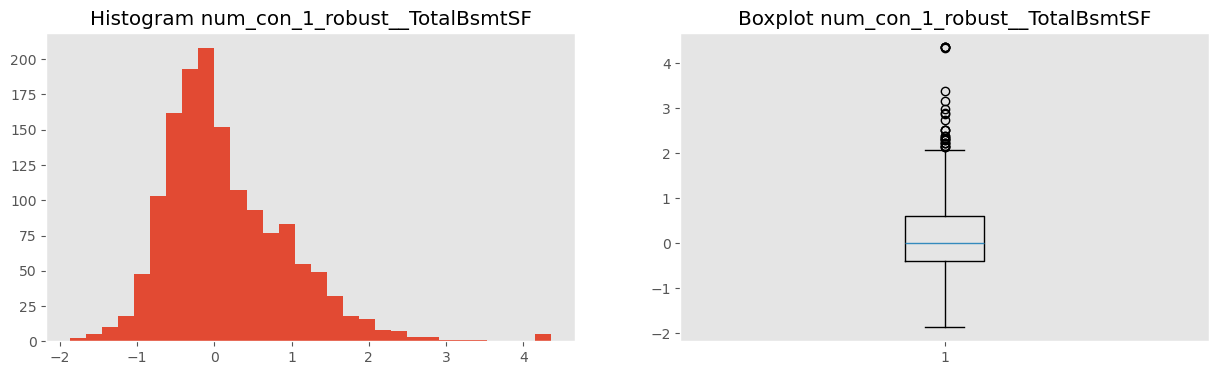

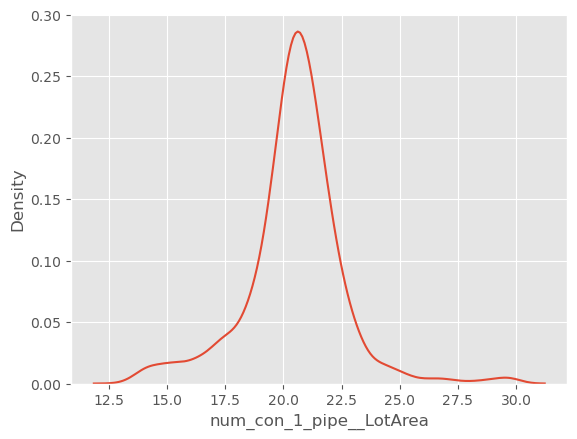

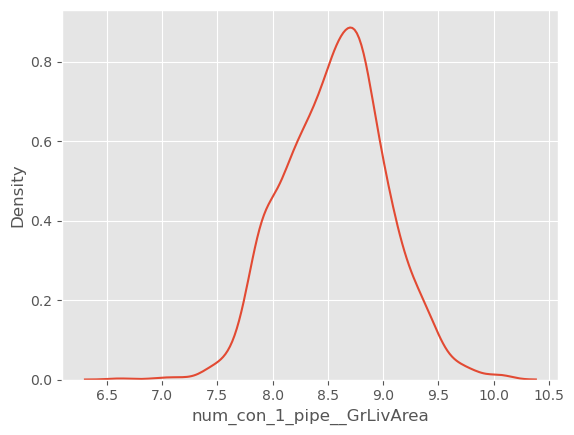

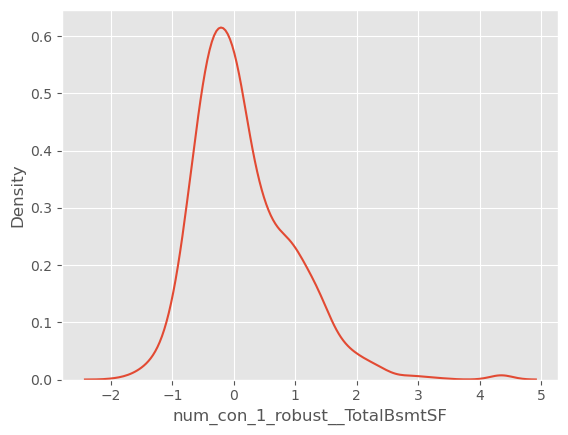

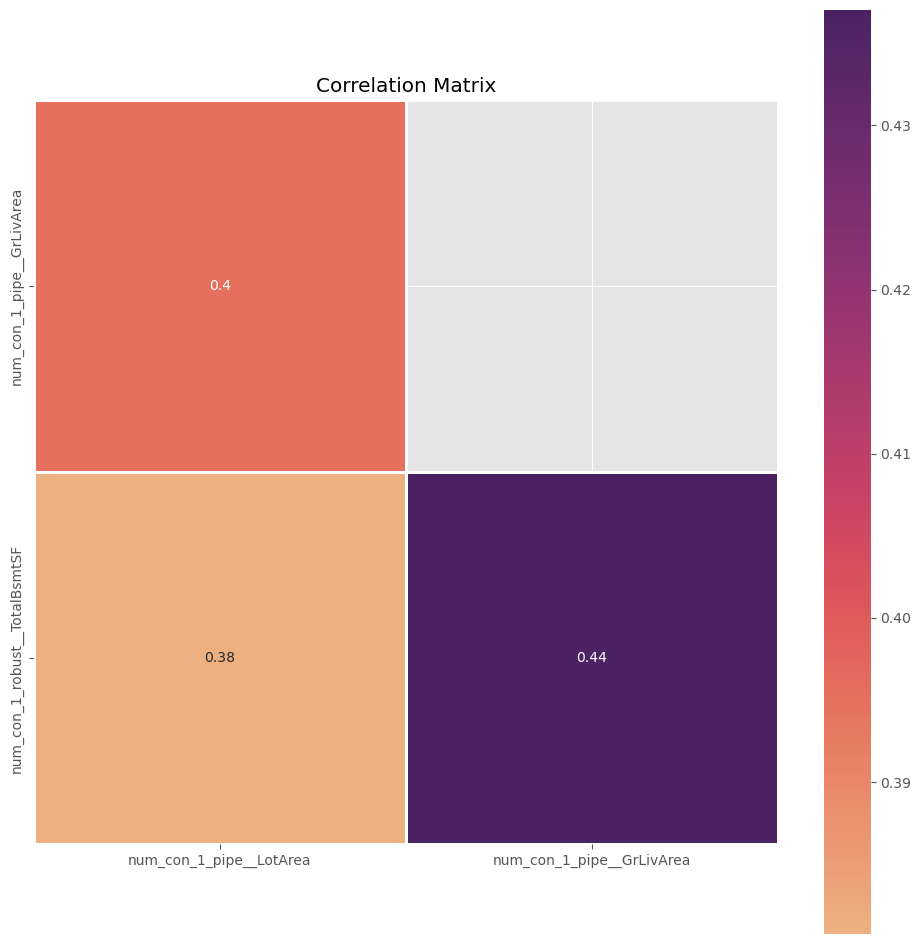

In [10]:
plot_numerical_data(X_train_trans.filter(regex='num_con_1_'), target=None)

In [11]:
X_train_trans.filter(regex='num_con_1_')

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_1_robust__TotalBsmtSF
0,20.108111,8.809113,-0.306895
1,20.647115,8.390301,0.534992
2,21.332458,8.869521,-0.174184
3,20.624842,8.814783,-0.514256
4,22.389555,9.159469,0.292379
...,...,...,...
1455,19.837050,8.757060,-0.105754
1456,22.032293,9.077412,1.115604
1457,20.392798,9.247438,0.306895
1458,20.698855,8.175244,0.153447


In [12]:
np.corrcoef(X_train_trans['num_con_1_pipe__LotArea'], y_train)

array([[1.        , 0.39702323],
       [0.39702323, 1.        ]])

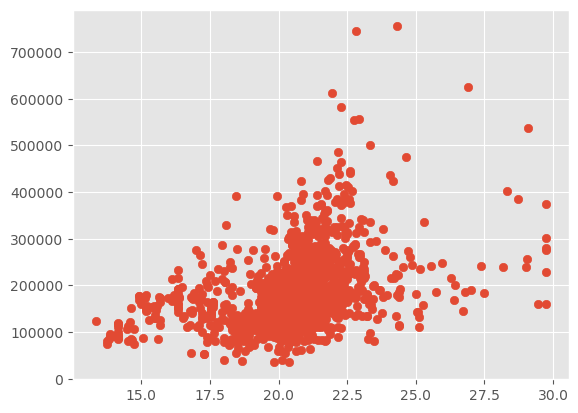

In [13]:
plt.scatter(
    x=X_train_trans['num_con_1_pipe__LotArea'],
    y=y_train
                );

In [14]:
np.corrcoef(X_train_trans['num_con_1_pipe__GrLivArea'], y_train)

array([[1.        , 0.69811727],
       [0.69811727, 1.        ]])

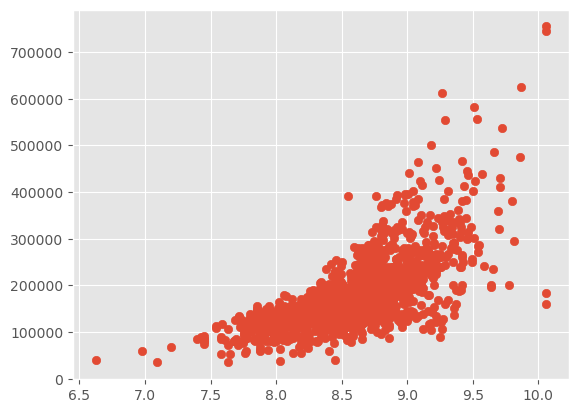

In [15]:
plt.scatter(
    x=X_train_trans['num_con_1_pipe__GrLivArea'],
    y=y_train
                );

In [16]:
np.corrcoef(X_train_trans['num_con_1_robust__TotalBsmtSF'], y_train)

array([[1.       , 0.6368839],
       [0.6368839, 1.       ]])

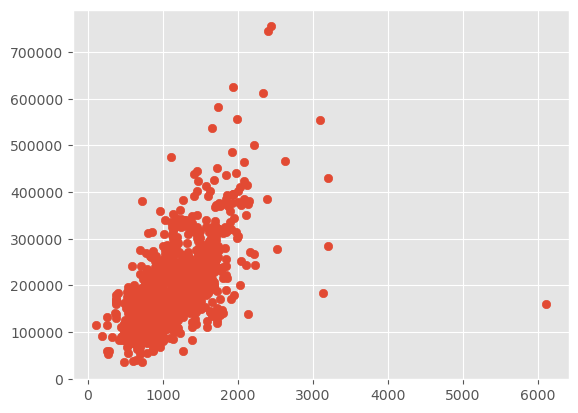

In [17]:
plt.scatter(
    x=X_train['TotalBsmtSF'],
    y=y_train
                );

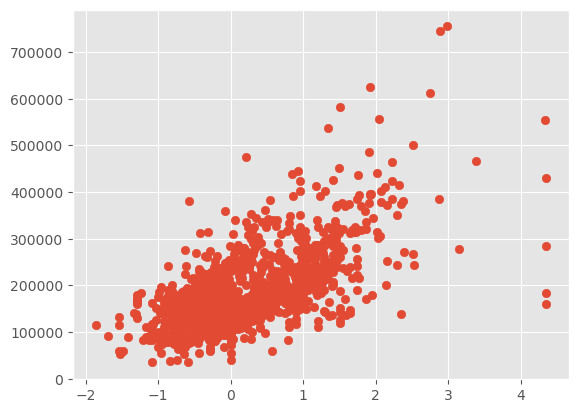

In [18]:
plt.scatter(
    x=X_train_trans['num_con_1_robust__TotalBsmtSF'],
    y=y_train
                );

In [19]:
# for col in X_train_trans.filter(like='categorical').columns:
#     Bar_plot(X_train_trans[col].value_counts(), title=col)

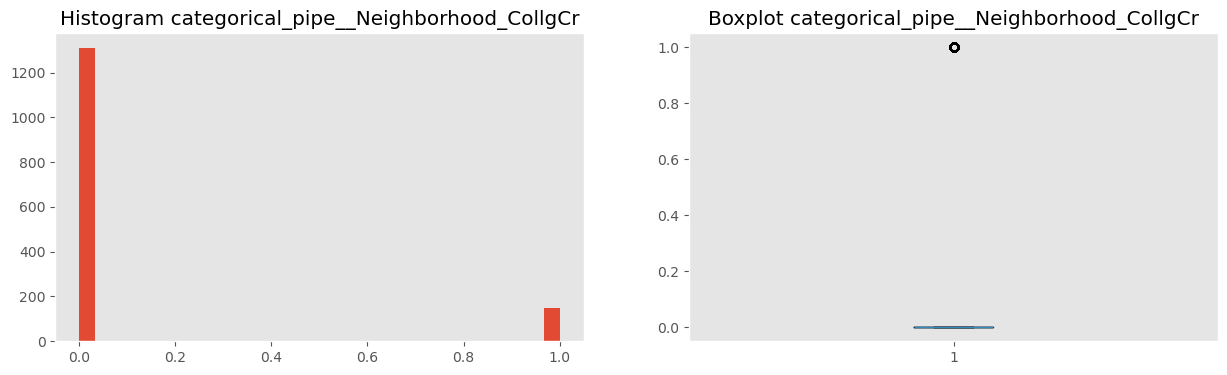

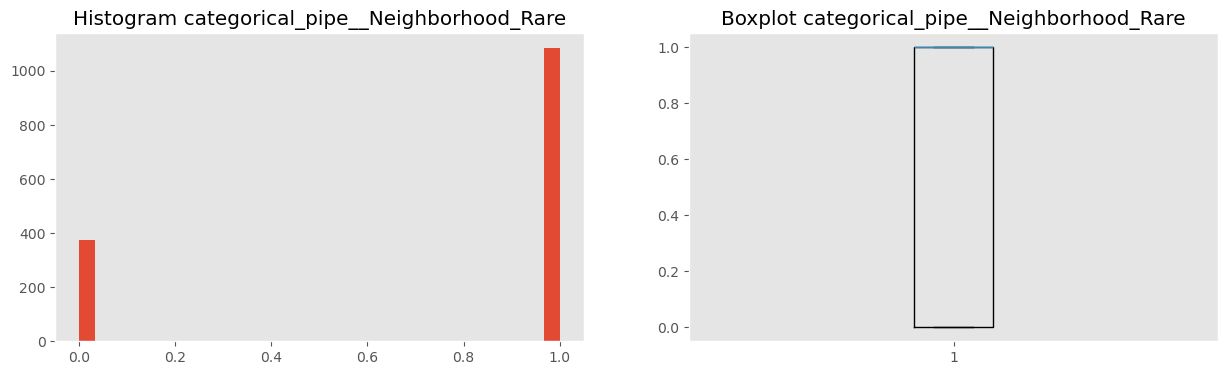

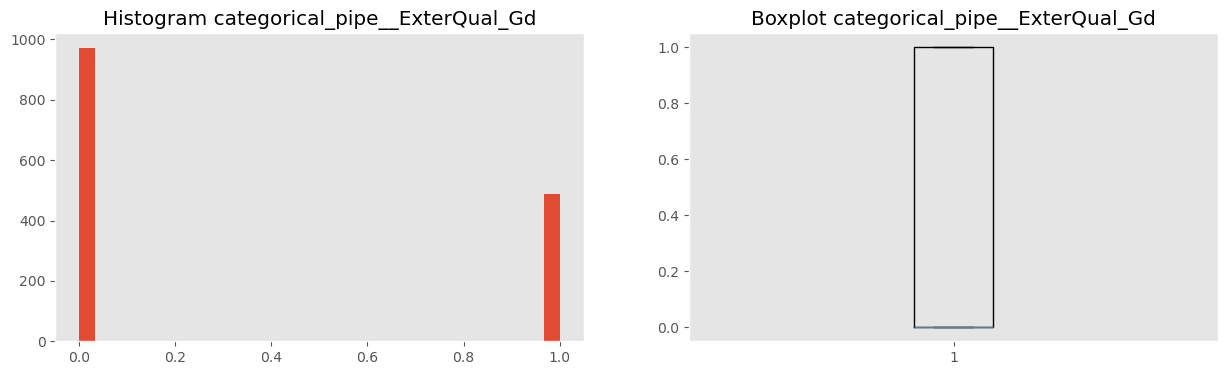

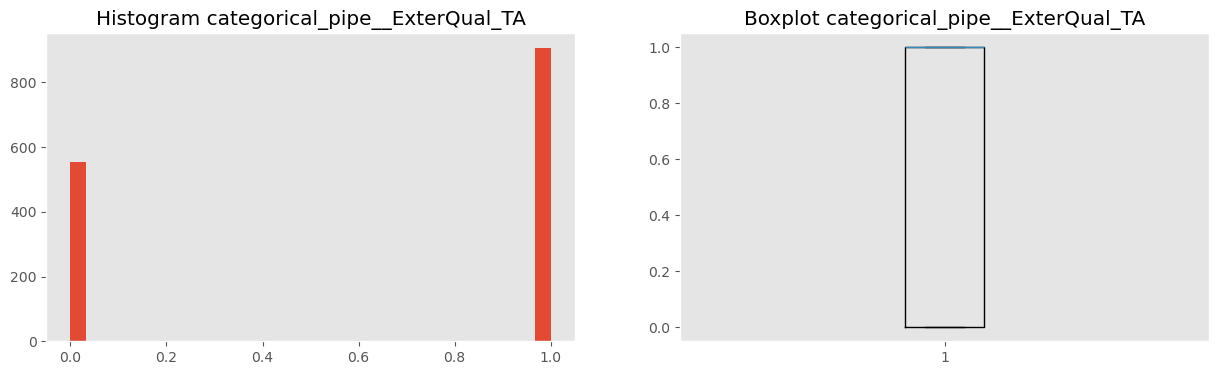

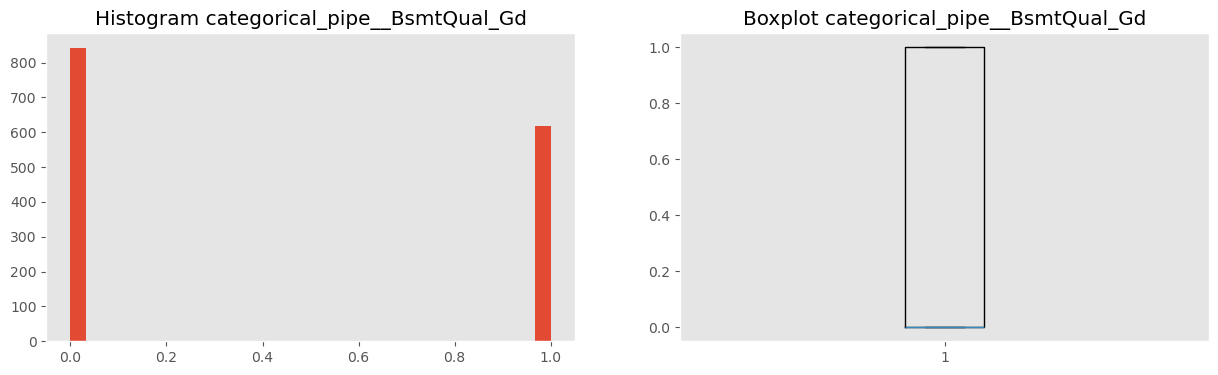

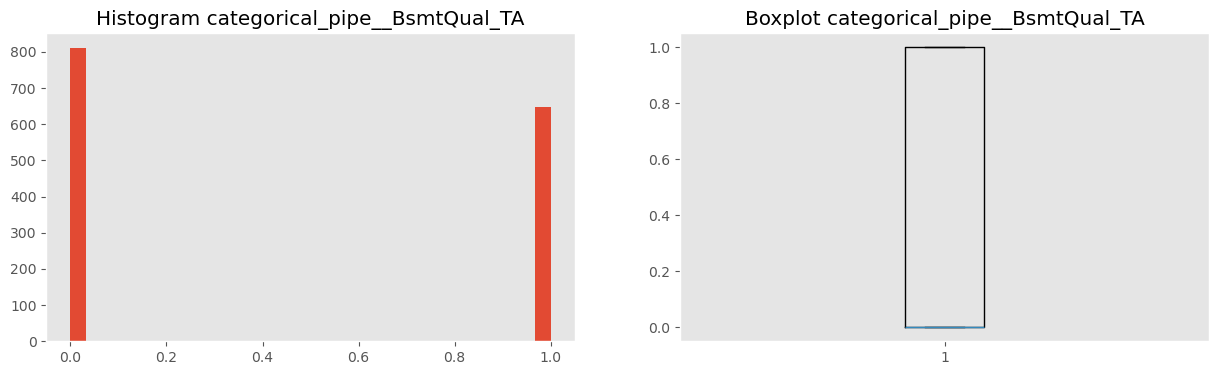

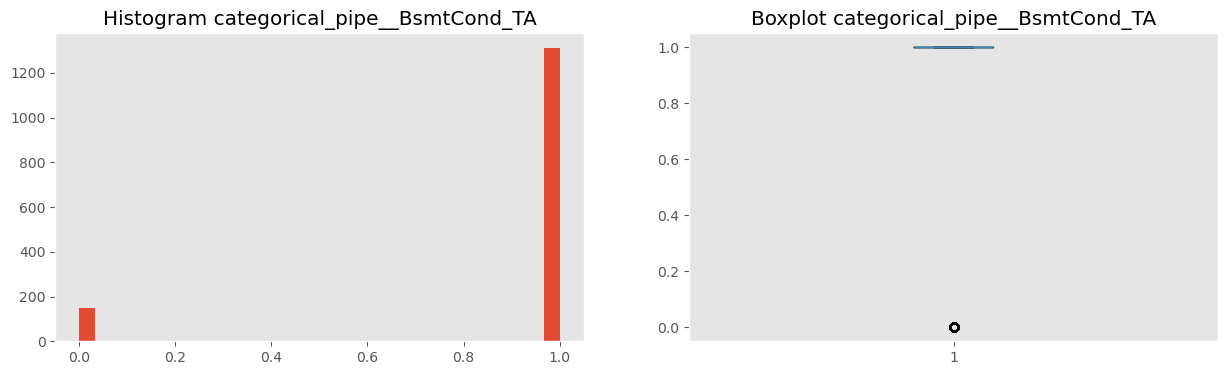

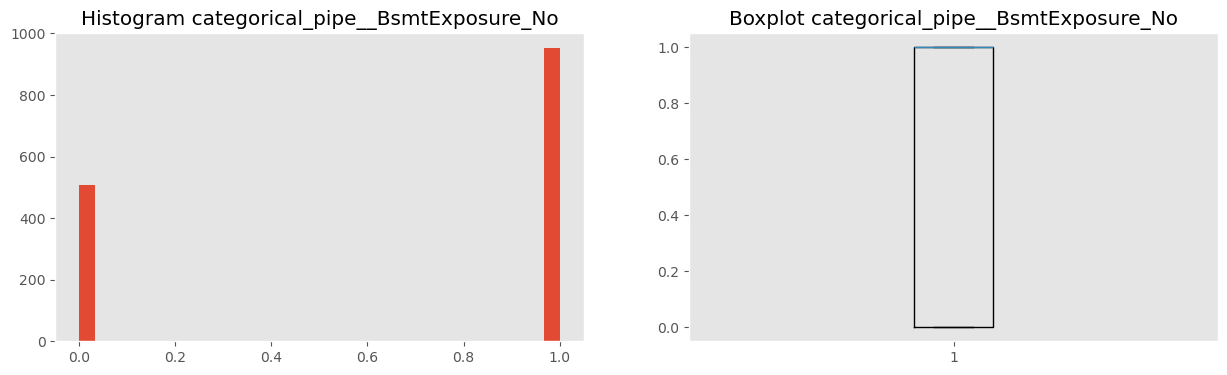

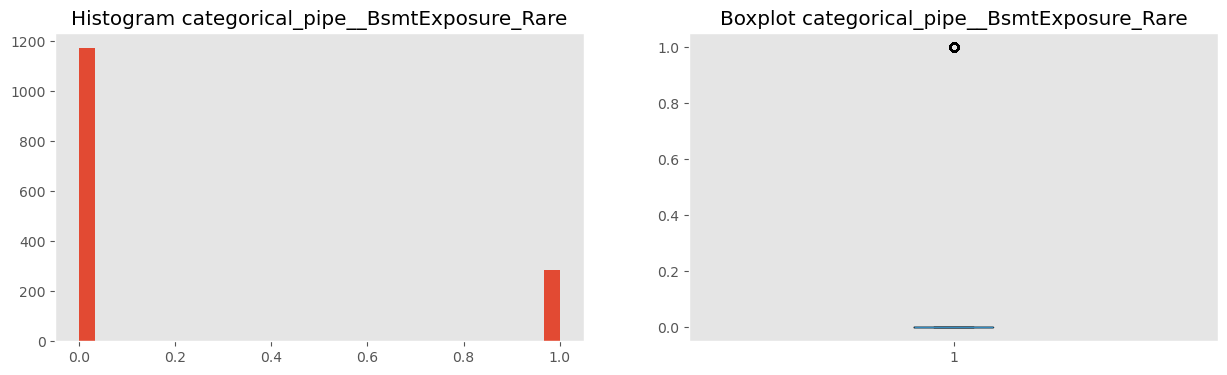

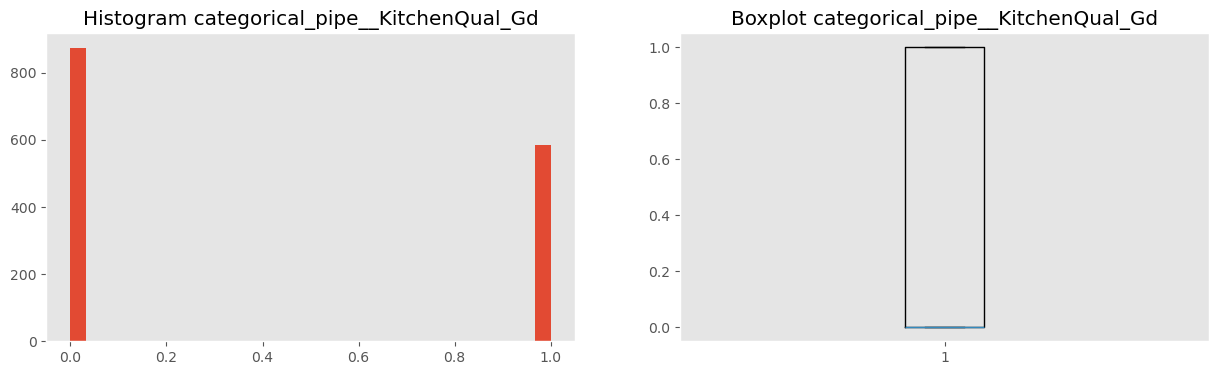

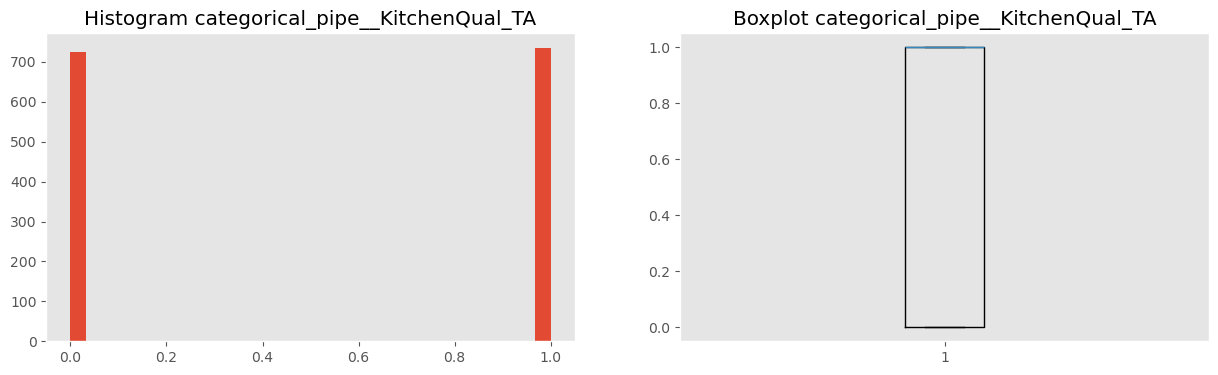

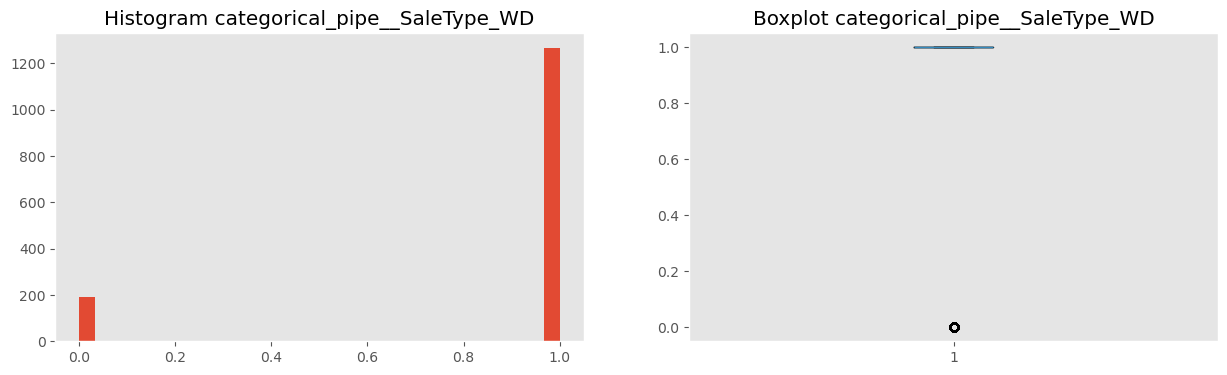

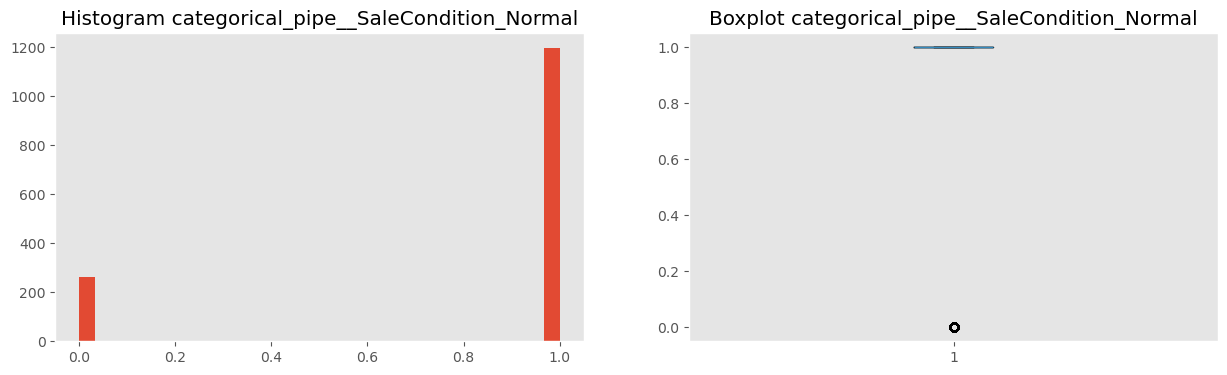

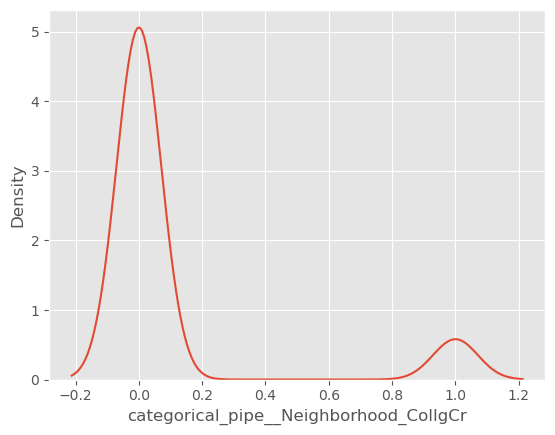

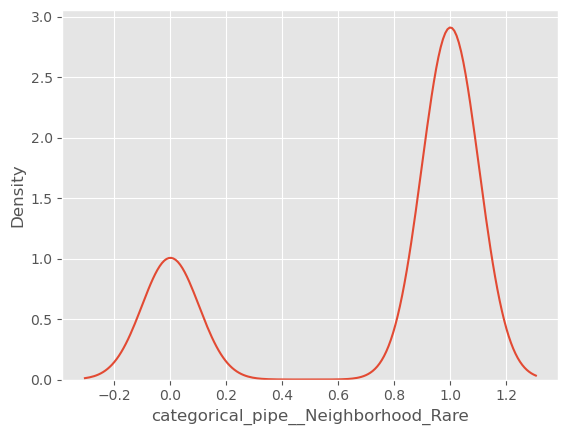

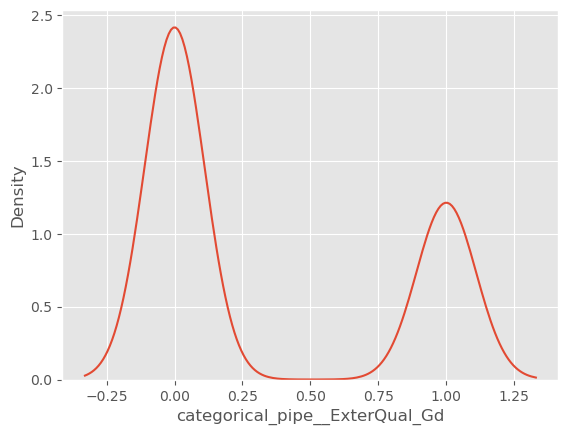

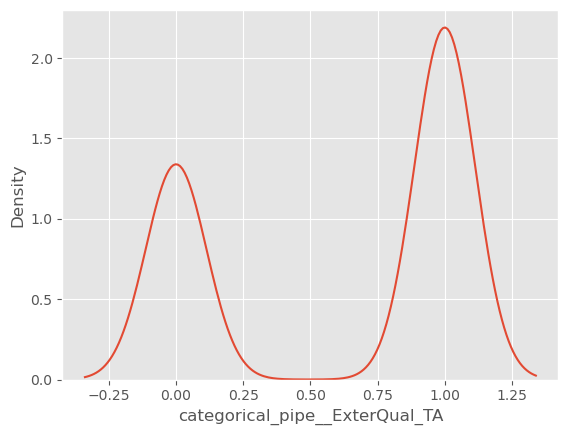

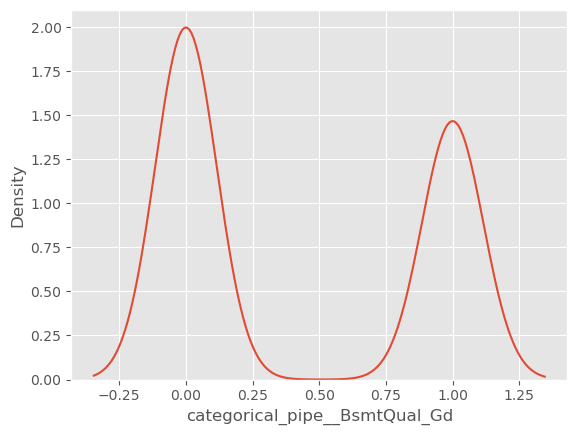

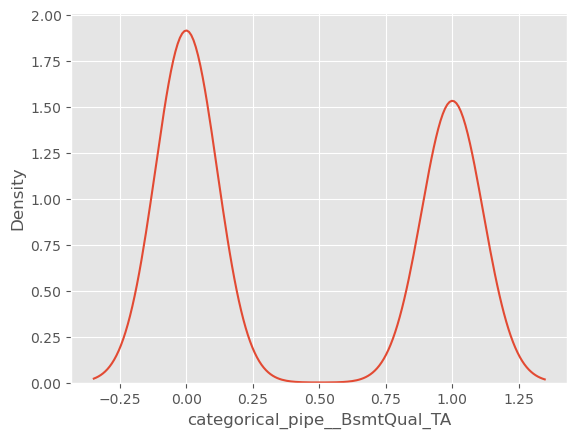

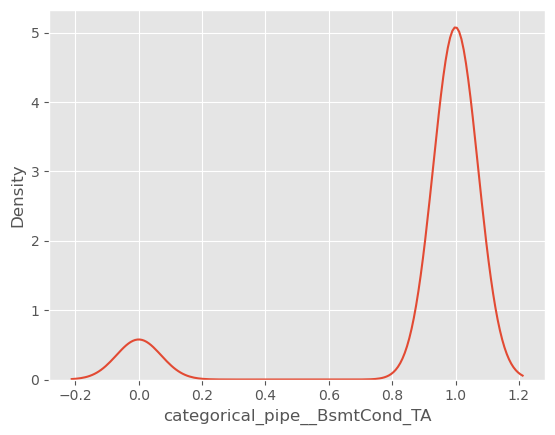

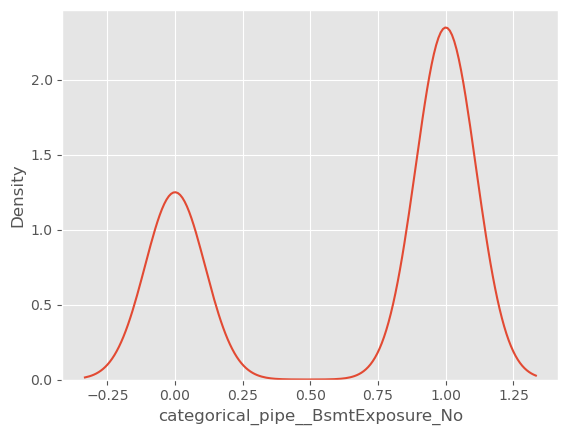

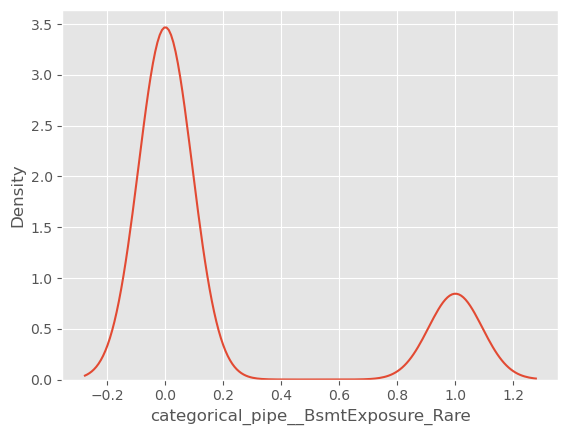

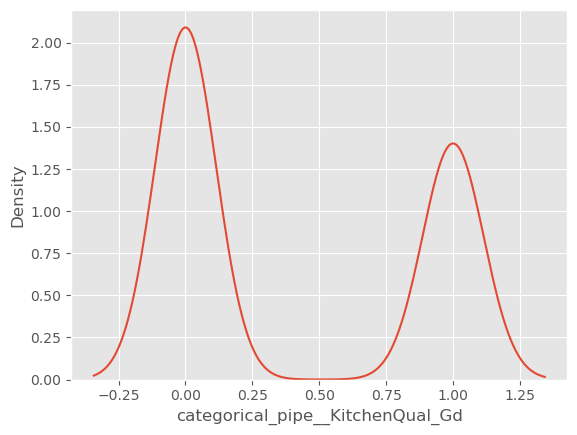

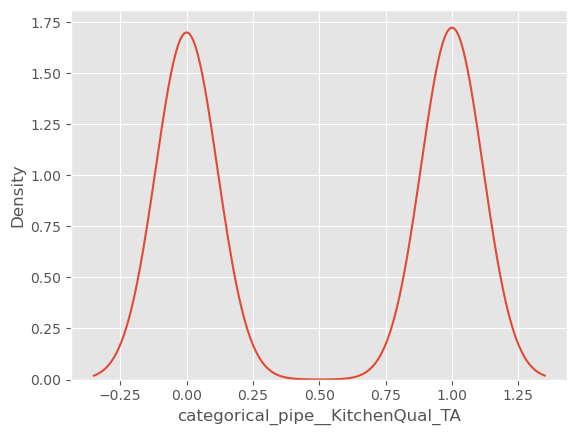

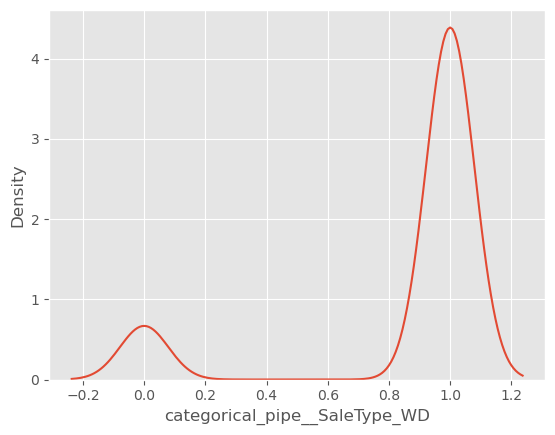

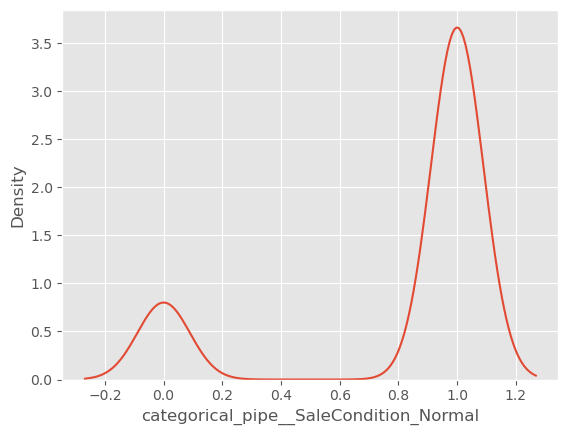

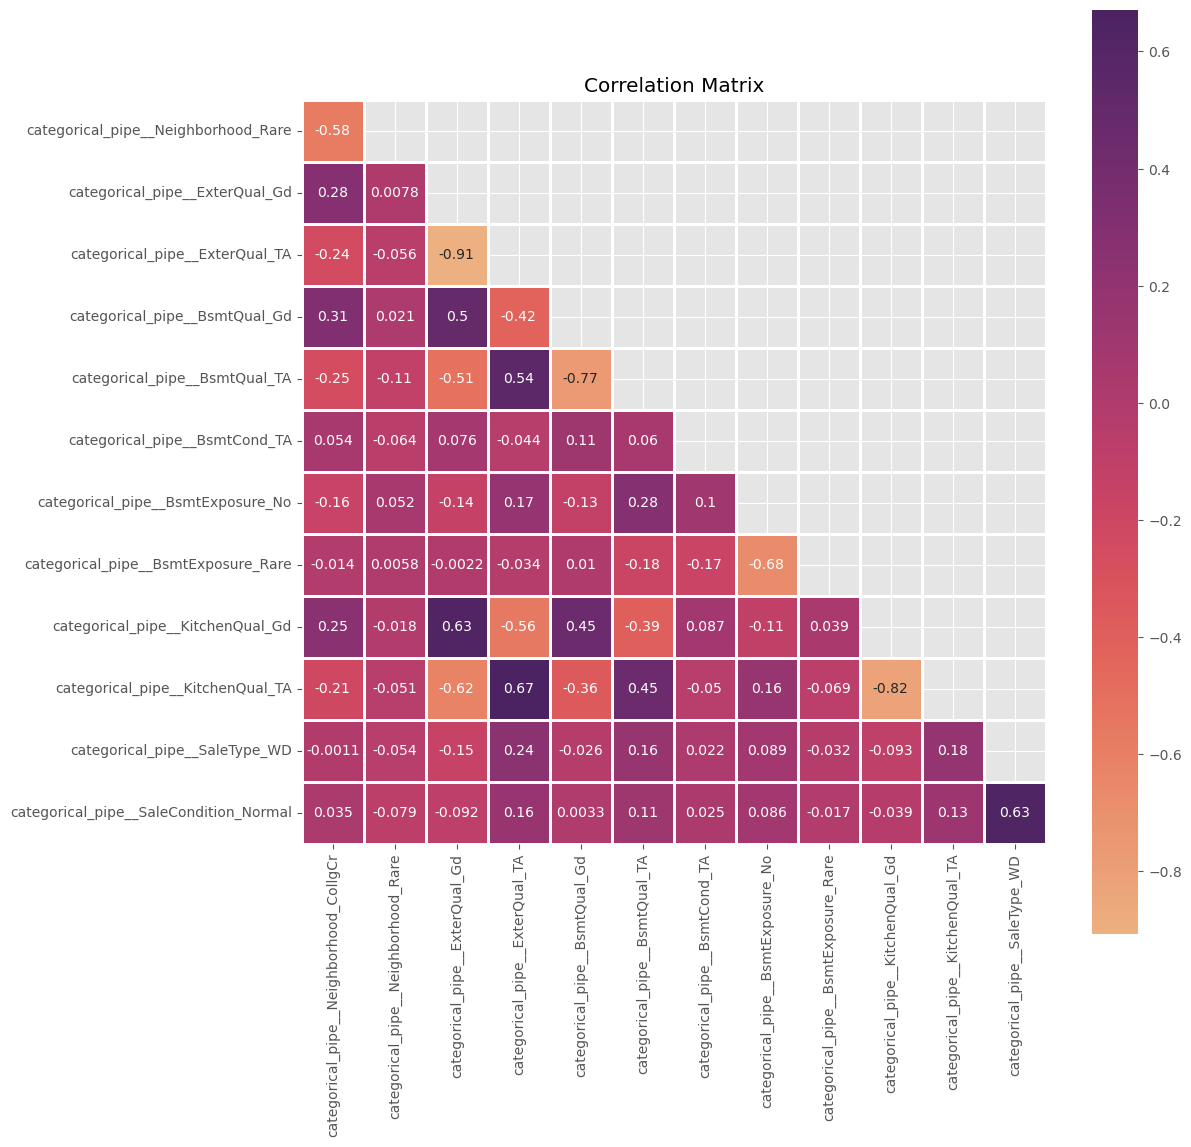

In [20]:
plot_numerical_data(X_train_trans.filter(regex='categorical'), target=None)

# Univariate Feat Selection

## Orquestrador

In [21]:
X_train_trans.filter(like='num')

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__HalfBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__BsmtFullBath,num_con_1_robust__TotalBsmtSF
0,20.108111,8.809113,7,7,8,0,6,8,7,2,1,3,1,-0.306895
1,20.647115,8.390301,0,7,0,8,0,8,6,2,0,3,0,0.534992
2,21.332458,8.869521,6,7,8,0,5,8,7,2,1,3,1,-0.174184
3,20.624842,8.814783,0,6,8,0,5,8,7,1,0,3,1,-0.514256
4,22.389555,9.159469,7,7,9,7,7,9,8,2,1,4,1,0.292379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,19.837050,8.757060,0,0,8,0,5,8,6,2,1,3,0,-0.105754
1456,22.032293,9.077412,6,7,0,8,0,8,6,2,0,3,1,1.115604
1457,20.392798,9.247438,0,6,9,0,6,7,7,2,0,4,0,0.306895
1458,20.698855,8.175244,0,4,0,8,0,7,5,1,0,2,1,0.153447


In [22]:
feature_selection = FeatureSelectionOrchestrator()

## Constant Features

In [23]:
constant_features = feature_selection.apply(
        "DropConstantFeatures", 
        X_train_trans, 
        y_train,
        threshold=0.90)

constant_features

[]

## Duplicate Features

In [24]:
duplicate_features = feature_selection.apply(
        "DropDuplicateFeatures", 
        X_train_trans,        
        y_train
        )

duplicate_features

set()

In [ ]:
# QuiSquare = feature_selection.apply(
#         "QuiSquare", 
#         X_train_trans.filter(like='categorical'), 
#         y_train)

# [i
#     for i in QuiSquare.loc[QuiSquare < 0.05].index
# ]

# # feature selection based on QuiSquare test
# [i
#     for i in QuiSquare.loc[QuiSquare > 0.05].index
# ]

## Anova

In [25]:
Anova = feature_selection.apply(
        "Anova",
        X_train_trans.filter(like='num'),
        y_train.values)

In [26]:
Anova.loc[Anova > 0.05]

Series([], Name: Anova, dtype: float64)

In [27]:
Anova.loc[Anova < 0.05]

num_dis_pipe__OverallQual        1.344399e-114
num_con_1_pipe__GrLivArea         1.799364e-59
num_con_1_robust__TotalBsmtSF     1.812656e-41
num_dis_pipe__FullBath            5.306331e-40
num_con_2_pipe__OpenPorchSF       1.985910e-11
num_con_2_pipe__GarageArea        7.588050e-09
num_con_2_pipe__MasVnrArea        4.170467e-07
num_dis_pipe__HalfBath            1.410758e-06
num_con_1_pipe__LotArea           7.185116e-06
num_con_2_pipe__BsmtFinSF1        4.023059e-05
num_con_2_pipe__WoodDeckSF        9.908564e-05
num_dis_pipe__BedroomAbvGr        2.144007e-03
num_con_2_pipe__2ndFlrSF          1.860987e-02
num_dis_pipe__BsmtFullBath        4.326529e-02
Name: Anova, dtype: float64

## Mutual Info

In [28]:
mi = feature_selection.apply(
        "MutualInformationReg", 
        X_train_trans, 
        y_train)

In [29]:
mi

num_dis_pipe__OverallQual                 0.568777
num_con_1_pipe__GrLivArea                 0.493241
num_con_1_robust__TotalBsmtSF             0.363224
num_con_2_pipe__GarageArea                0.275910
num_dis_pipe__FullBath                    0.272376
categorical_pipe__ExterQual_TA            0.248240
categorical_pipe__KitchenQual_TA          0.232871
categorical_pipe__ExterQual_Gd            0.215158
categorical_pipe__BsmtQual_TA             0.185203
num_con_1_pipe__LotArea                   0.184778
categorical_pipe__KitchenQual_Gd          0.178222
categorical_pipe__BsmtQual_Gd             0.172074
num_con_2_pipe__OpenPorchSF               0.147522
num_con_2_pipe__MasVnrArea                0.114736
num_con_2_pipe__BsmtFinSF1                0.105145
num_con_2_pipe__2ndFlrSF                  0.094370
num_con_2_pipe__WoodDeckSF                0.086252
num_dis_pipe__HalfBath                    0.085019
num_dis_pipe__BedroomAbvGr                0.069438
categorical_pipe__SaleType_WD  

## Correlation

In [30]:
   
corr = feature_selection.apply(
        "PearsonCorrelation", 
        X_train_trans.filter(like='num'), 
        y_train)

In [31]:
corr

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__HalfBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__BsmtFullBath,num_con_1_robust__TotalBsmtSF
num_con_1_pipe__LotArea,1.000000,0.395227,0.080899,0.104491,-0.005269,0.131962,0.142994,0.213407,0.185997,0.184003,0.052200,0.277012,0.140177,0.380752
num_con_1_pipe__GrLivArea,0.395227,1.000000,0.304002,-0.010219,0.560453,0.218804,0.392884,0.313450,0.613372,0.654180,0.430961,0.540688,0.018801,0.437032
num_con_2_pipe__MasVnrArea,0.080899,0.304002,1.000000,0.186864,-0.011705,0.164842,0.205187,0.249939,0.410652,0.276196,0.150823,0.092699,0.115089,0.358629
num_con_2_pipe__BsmtFinSF1,0.104491,-0.010219,0.186864,1.000000,-0.206972,0.089192,0.013142,0.116020,0.057804,-0.082270,-0.006566,-0.094150,0.594347,0.228842
num_con_2_pipe__2ndFlrSF,-0.005269,0.560453,-0.011705,-0.206972,1.000000,0.038247,0.168917,0.047389,0.196317,0.319357,0.586497,0.441121,-0.212888,-0.352676
num_con_2_pipe__WoodDeckSF,0.131962,0.218804,0.164842,0.089192,0.038247,1.000000,0.131081,0.164214,0.279158,0.228179,0.110790,0.016865,0.165182,0.204058
num_con_2_pipe__OpenPorchSF,0.142994,0.392884,0.205187,0.013142,0.168917,0.131081,1.000000,0.191134,0.442274,0.377641,0.259301,0.084890,0.077678,0.270339
num_con_2_pipe__GarageArea,0.213407,0.313450,0.249939,0.116020,0.047389,0.164214,0.191134,1.000000,0.396872,0.241302,0.143237,0.023784,0.088524,0.270098
num_dis_pipe__OverallQual,0.185997,0.613372,0.410652,0.057804,0.196317,0.279158,0.442274,0.396872,1.000000,0.550600,0.273458,0.101676,0.111098,0.510700
num_dis_pipe__FullBath,0.184003,0.654180,0.276196,-0.082270,0.319357,0.228179,0.377641,0.241302,0.550600,1.000000,0.136381,0.363252,-0.064512,0.370545


## Smart Corr

In [32]:
smart_corr = feature_selection.apply(
        "SmartCorrelatedSelection",
        X_train_trans,
        y_train)

smart_corr

{'corr_feature': ['categorical_pipe__ExterQual_TA',
  'categorical_pipe__ExterQual_Gd'],
 'corr_2_drop': ['categorical_pipe__ExterQual_Gd',
  'categorical_pipe__KitchenQual_TA']}

## MRMR

In [33]:
mrmr = feature_selection.apply(
        "MRMR",        
        X_train_trans,
        y_train,
        method="MIQ"
        )

In [34]:
X_train_trans.shape

(1460, 27)

In [35]:
len(mrmr['features_to_drop'])

22

In [36]:
mrmr['features_to_drop'] 

['num_con_1_pipe__LotArea',
 'num_con_2_pipe__MasVnrArea',
 'num_con_2_pipe__BsmtFinSF1',
 'num_con_2_pipe__2ndFlrSF',
 'num_con_2_pipe__WoodDeckSF',
 'num_con_2_pipe__OpenPorchSF',
 'num_con_2_pipe__GarageArea',
 'num_dis_pipe__OverallQual',
 'num_dis_pipe__FullBath',
 'num_dis_pipe__HalfBath',
 'num_dis_pipe__BedroomAbvGr',
 'num_dis_pipe__BsmtFullBath',
 'categorical_pipe__Neighborhood_CollgCr',
 'categorical_pipe__ExterQual_Gd',
 'categorical_pipe__ExterQual_TA',
 'categorical_pipe__BsmtQual_Gd',
 'categorical_pipe__BsmtQual_TA',
 'categorical_pipe__BsmtExposure_Rare',
 'categorical_pipe__KitchenQual_Gd',
 'categorical_pipe__KitchenQual_TA',
 'categorical_pipe__SaleType_WD',
 'num_con_1_robust__TotalBsmtSF']

In [ ]:
mrmr['relevance']